<a href="https://colab.research.google.com/github/joshua-y-hub/crisps/blob/main/Crisps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/Potato_slices'
print("Directory exists:", os.path.exists(BASE_DIR))

Mounted at /content/drive
Directory exists: True


In [2]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split

# Corrected paths based on directory listing
HEALTHY_SINGLE_DIR = os.path.join(BASE_DIR,'healthy slices','single')
DEFECTED_SINGLE_DIR = os.path.join(BASE_DIR,'defected slices','single')

healthy_paths= []
for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.PNG']:
  healthy_paths.extend(glob.glob(os.path.join(HEALTHY_SINGLE_DIR,ext)))

defected_paths=[]
for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.PNG']:
  defected_paths.extend(glob.glob(os.path.join(DEFECTED_SINGLE_DIR,ext)))

file_paths = np.array(healthy_paths + defected_paths)
labels = np.array([0]*len(healthy_paths) + [1]*len(defected_paths))

print(f"Total Healthy images: {len(healthy_paths)}")
print(f"Total Defected images: {len(defected_paths)}")

Total Healthy images: 718
Total Defected images: 738


In [3]:
from sklearn.model_selection import train_test_split

# First split: 80% Train+Val, 20% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    file_paths, labels, test_size=0.20, random_state=42, stratify=labels
)

# Second split: Split Train+Val into 80% Train (64% total) and 20% Val (16% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=42, stratify=y_train_val
)

print(f"Train Set:      {len(X_train)} images")
print(f"Validation Set: {len(X_val)} images")
print(f"Test Set:       {len(X_test)} images")

Train Set:      931 images
Validation Set: 233 images
Test Set:       292 images


In [4]:
!pip install opencv-python
import numpy as np # Import numpy here as it is used in the next cell and is often paired with opencv

In [5]:
import cv2
import pandas as pd
from skimage.feature import graycomatrix,graycoprops
import matplotlib.pyplot as plt

def extract_raw_features(image_path):
    # Read image using OpenCV (loads in BGR format)
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    # Convert BGR color space to HSV and CIELAB
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 1. Solanine/Greening Detection (HSV Space)
    # Green hues fall roughly between angle 35 and 85
    green_mask = cv2.inRange(img_hsv,(35,40,40),(85,255,255))
    green_ratio = np.sum(green_mask>0)/img_gray.size

    # 2. Blackspot & Rot Detection (CIELAB Space - L* Lightness channel)
    l_channel = img_lab[:,:,0]
    dark_defect_ratio = np.sum(l_channel<80)/l_channel.size

    # 3. GLCM Texture Feature Extraction
    img_glcm = (img_gray//8).astype(np.uint8)
    glcm = graycomatrix(img_glcm,distances =[1],angles=[0],levels=32,symmetric=True,normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return {
        'green_solanine_ratio': green_ratio,
        'dark_defect_ratio': dark_defect_ratio,
        'mean_lightness_L': np.mean(l_channel),
        'texture_contrast': contrast,
        'texture_homogeneity': homogeneity
    }

# Run feature analysis across the training split
features_list = []
for path, label in zip(X_train, y_train):
    feats = extract_raw_features(path)
    if feats:
        feats['label'] = 'defected' if label == 1 else 'healthy'
        features_list.append(feats)

df_features = pd.DataFrame(features_list)

print("=== Feature Analysis Averages (Healthy vs Defected Raw Slices) ===")
print(df_features.groupby('label').mean())

=== Feature Analysis Averages (Healthy vs Defected Raw Slices) ===
          green_solanine_ratio  dark_defect_ratio  mean_lightness_L  \
label                                                                 
defected                   0.0           0.006404        178.114721   
healthy                    0.0           0.001406        151.445366   

          texture_contrast  texture_homogeneity  
label                                            
defected          0.461847             0.898447  
healthy           0.283421             0.887904  


In [12]:
!pip install tensorflow

IMG_SIZE = (380, 380)  # Native input resolution for EfficientNetB4
BATCH_SIZE = 16

In [7]:
# Data Augmentation pipeline tailored for raw agricultural slices
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.5, fill_mode='nearest'),
    tf.keras.layers.RandomZoom(0.15, fill_mode='nearest'),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="raw_slice_augmentation")

In [8]:
# Helper function to read, decode, and resize images from file paths
def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

In [9]:
# Construct tf.data input pipelines
def create_tf_dataset(paths, labels, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

In [10]:
train_ds = create_tf_dataset(X_train, y_train, shuffle=True)
val_ds = create_tf_dataset(X_val, y_val, shuffle=False)
test_ds = create_tf_dataset(X_test, y_test, shuffle=False)

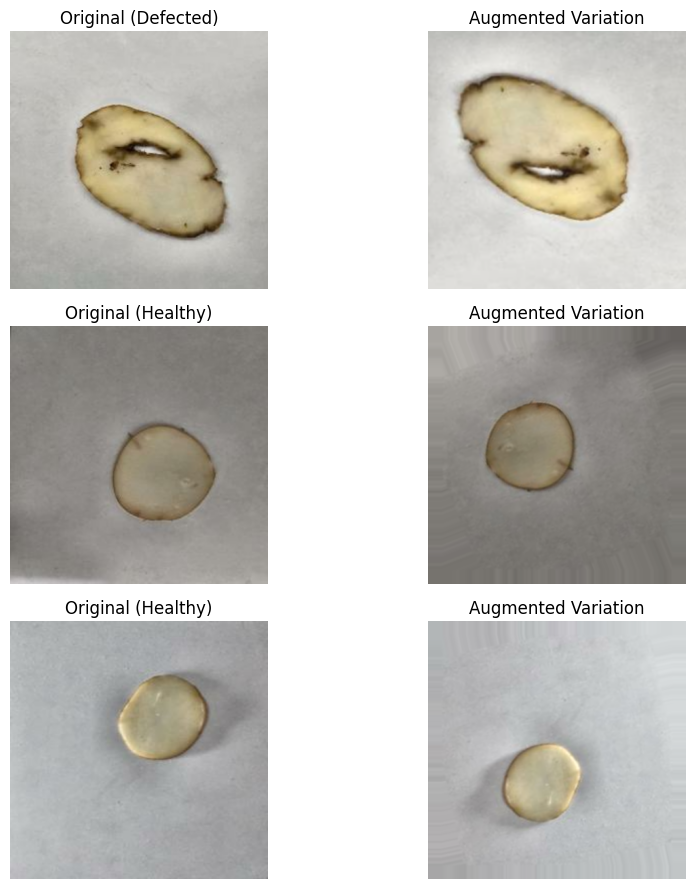

In [11]:
import matplotlib.pyplot as plt

def visualize_augmentation(dataset, num_samples=3):
    for images, labels in dataset.take(1):
        plt.figure(figsize=(10, 3 * num_samples))
        for i in range(num_samples):
            # Extract raw image tensor
            orig_img = images[i].numpy().astype("uint8")

            # Pass image tensor through the augmentation pipeline
            aug_img = data_augmentation(tf.expand_dims(images[i], 0))
            aug_img = tf.squeeze(aug_img, 0).numpy().astype("uint8")

            class_name = "Defected" if labels[i] == 1 else "Healthy"

            # Plot original image
            plt.subplot(num_samples, 2, 2 * i + 1)
            plt.imshow(orig_img)
            plt.title(f"Original ({class_name})")
            plt.axis("off")

            # Plot augmented variation
            plt.subplot(num_samples, 2, 2 * i + 2)
            plt.imshow(aug_img)
            plt.title("Augmented Variation")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# Display sample augmentations
visualize_augmentation(train_ds, num_samples=3)

In [13]:
import tensorflow as tf

In [14]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models

# 1. Load pre-trained EfficientNetB4 base model
base_model = EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(380, 380, 3)
)
base_model.trainable = False  # Freeze base model initially

# 2. Build custom classification network architecture
inputs = layers.Input(shape=(380, 380, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs, name="RawPotatoSlice_Classifier")

# 3. Phase 1: Train Classification Head Only
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("--- Phase 1: Training Classification Head ---")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

# 4. Phase 2: Fine-Tune Top Layers
base_model.trainable = True
for layer in base_model.layers[:-40]:  # Unfreeze only the top 40 layers
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("\n--- Phase 2: Fine-Tuning EfficientNetB4 Top Layers ---")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12
)

# Save the final model to Drive
# Changed the file extension from .h5 to .keras as recommended for modern Keras models
model.save(os.path.join(BASE_DIR, 'raw_potato_slice_model.keras'))
print("\nTraining completed successfully! Model saved to Google Drive.")

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
--- Phase 1: Training Classification Head ---
Epoch 1/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 64s 635ms/step - accuracy: 0.9377 - loss: 0.1775 - precision: 0.9386 - recall: 0.9386 - val_accuracy: 0.9227 - val_loss: 0.1959 - val_precision: 0.8676 - val_recall: 1.0000
Epoch 2/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 360ms/step - accuracy: 0.9753 - loss: 0.0656 - precision: 0.9746 - recall: 0.9767 - val_accuracy: 0.9957 - val_loss: 0.0391 - val_precision: 0.9916 - val_recall: 1.0000
Epoch 3/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 367ms/step - accuracy: 0.9893 - loss: 0.0292 - precision: 0.9894 - recall: 0.9894 - val_accuracy: 0.9957 - val_loss: 0.0254 - val_precision: 0.9916 - val_recall: 1.0000
Epoch 4/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 377ms/step - accuracy: 0.9903 - loss: 0.0388 - precision: 0.9894 - recall: 0.9915 - val_accuracy: 0.9957 - val_loss: 0.0215 - val_precision: 0.9916 - val_recall: 1.0000
Epoch 5/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 360ms/step - accuracy:

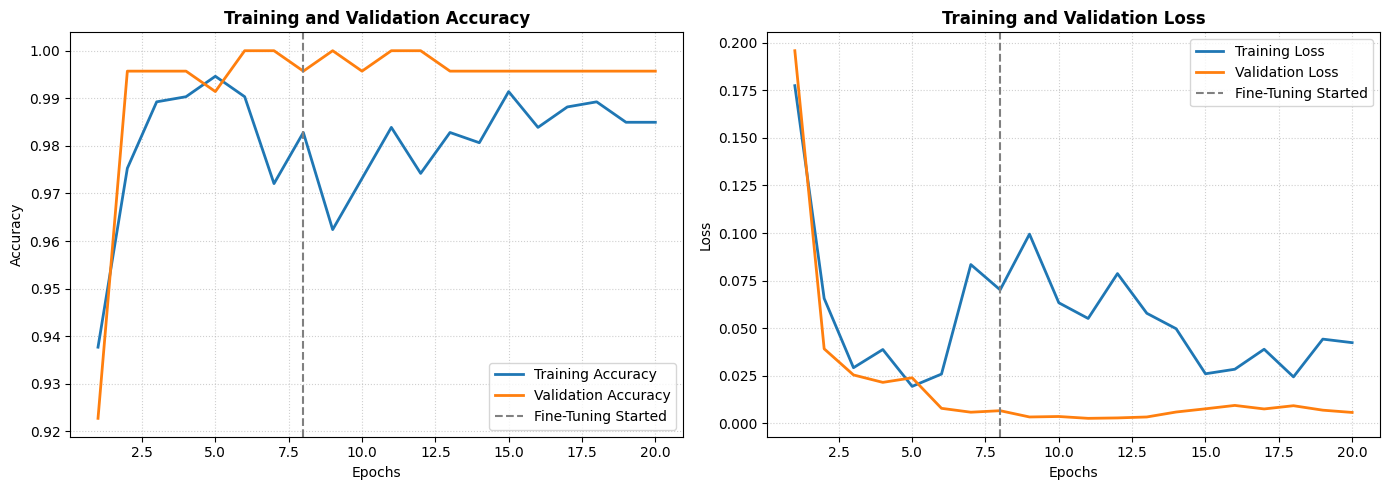

In [15]:
import matplotlib.pyplot as plt

# 1. Combine training metrics across Phase 1 and Phase 2
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

epochs_range = range(1, len(acc) + 1)
phase1_epochs = len(history_phase1.history['accuracy'])

# 2. Plot Accuracy and Loss Curves
plt.figure(figsize=(14, 5))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
plt.axvline(x=phase1_epochs, color='gray', linestyle='--', label='Fine-Tuning Started')
plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.axvline(x=phase1_epochs, color='gray', linestyle='--', label='Fine-Tuning Started')
plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
scores= model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9966 - loss: 0.0047 - precision_1: 0.9933 - recall_1: 1.0000


In [19]:
scores

[0.004694554954767227, 0.9965753555297852, 0.9932885766029358, 1.0]

In [16]:
import random

def generate_synthetic_batch(output_dir='/content/drive/MyDrive/Potato_slices/synthetic_dataset', num_healthy=500, num_defected=500):
    # Create subdirectories for output
    healthy_dir = os.path.join(output_dir, 'healthy')
    defected_dir = os.path.join(output_dir, 'defected')
    os.makedirs(healthy_dir, exist_ok=True)
    os.makedirs(defected_dir, exist_ok=True)

    def build_slice(has_defect=False):
        # 1. Base canvas
        img = np.ones((380, 380, 3), dtype=np.uint8) * 255

        # 2. Add slight randomness to center, size, rotation, and color
        center = (190 + random.randint(-15, 15), 190 + random.randint(-15, 15))
        axes = (140 + random.randint(-15, 15), 110 + random.randint(-15, 15))
        angle = random.randint(0, 180)

        # Pale yellow flesh with slight random variation
        b_flesh = random.randint(165, 195)
        g_flesh = random.randint(220, 240)
        r_flesh = random.randint(235, 250)
        cv2.ellipse(img, center, axes, angle, 0, 360, (b_flesh, g_flesh, r_flesh), -1)

        # Outer skin rim
        skin_bgr = (random.randint(50, 80), random.randint(90, 120), random.randint(120, 150))
        cv2.ellipse(img, center, axes, angle, 0, 360, skin_bgr, random.randint(2, 4))

        # 3. Inject random defects if requested
        if has_defect:
            defect_type = random.choice(['green', 'rot', 'both'])

            # Greening (Solanine) along outer rim
            if defect_type in ['green', 'both']:
                start_arc = random.randint(0, 180)
                end_arc = start_arc + random.randint(60, 120)
                green_bgr = (random.randint(30, 70), random.randint(160, 200), random.randint(60, 100))
                thickness = random.randint(12, 22)
                cv2.ellipse(img, center, axes, angle, start_arc, end_arc, green_bgr, thickness)

            # Rot / Bruise patch
            if defect_type in ['rot', 'both']:
                rot_x = center[0] + random.randint(-40, 40)
                rot_y = center[1] + random.randint(-40, 40)
                rot_radius = random.randint(20, 40)
                rot_bgr = (random.randint(20, 40), random.randint(35, 55), random.randint(50, 70))
                cv2.circle(img, (rot_x, rot_y), rot_radius, rot_bgr, -1)

        return img

    # Generate and save healthy set
    for i in range(num_healthy):
        img = build_slice(has_defect=False)
        cv2.imwrite(os.path.join(healthy_dir, f'synth_healthy_{i+1:03d}.jpg'), img)

    # Generate and save defected set
    for i in range(num_defected):
        img = build_slice(has_defect=True)
        cv2.imwrite(os.path.join(defected_dir, f'synth_defected_{i+1:03d}.jpg'), img)

    print(f"Generated {num_healthy} healthy and {num_defected} defected synthetic slices in '{output_dir}/'")

# Execute generator
generate_synthetic_batch(num_healthy=500, num_defected=500)

Generated 500 healthy and 500 defected synthetic slices in '/content/drive/MyDrive/Potato_slices/synthetic_dataset/'


In [17]:
# ---------------------------------------------------------
# 1. DEFINE PREDICTION FUNCTION
# ---------------------------------------------------------
def predict_potato_slice(image_path, model, threshold=0.5):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not load image at {image_path}")
        return None, None

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Preprocess image for EfficientNetB4 (380x380 resolution)
    img_resized = cv2.resize(img_rgb, (380, 380))
    img_tensor = tf.expand_dims(img_resized, axis=0)

    # Run prediction
    prediction_score = model.predict(img_tensor, verbose=0)[0][0]

    # Assign class label based on threshold
    label = "DEFECTED" if prediction_score >= threshold else "HEALTHY"

    return label, prediction_score


# ---------------------------------------------------------
# 2. RUN BATCH PREDICTION ON SYNTHETIC IMAGES
# ---------------------------------------------------------
SYNTHETIC_DRIVE_DIR = '/content/drive/MyDrive/Potato_slices/synthetic_dataset'

# Fetch file paths
healthy_paths = glob.glob(os.path.join(SYNTHETIC_DRIVE_DIR, 'healthy', '*.jpg'))
defected_paths = glob.glob(os.path.join(SYNTHETIC_DRIVE_DIR, 'defected', '*.jpg'))

correct_predictions = 0
total_images = len(healthy_paths) + len(defected_paths)

# Test Healthy Subfolder
for path in healthy_paths:
    label, score = predict_potato_slice(path, model, threshold=0.5)
    if label == 'HEALTHY':
        correct_predictions += 1

# Test Defected Subfolder
for path in defected_paths:
    label, score = predict_potato_slice(path, model, threshold=0.5)
    if label == 'DEFECTED':
        correct_predictions += 1

# Display Accuracy Summary
print("="*45)
print(" SYNTHETIC TEST SET PREDICTION RESULTS ")
print("="*45)
print(f"Total Images Tested: {total_images}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Batch Accuracy:      {(correct_predictions / total_images) * 100:.2f}%")
print("="*45)

 SYNTHETIC TEST SET PREDICTION RESULTS 
Total Images Tested: 1000
Correct Predictions: 290
Batch Accuracy:      29.00%


to test the model with one brand new image directly ,one will be prompted in colab to upload the image in this one.

In [ ]:
from google.colab import files

# Trigger interactive browser file upload
uploaded = files.upload()

for file_name in uploaded.keys():
    print(f"\n--- Processing uploaded file: {file_name} ---")
    predict_potato_slice(file_name, model)

otherwise one could load a brand new image from the disk ,by this section of code ,defining the new img_path

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_potato_slice(image_path, model, threshold=0.5):
    # Load image using OpenCV
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not load image at {image_path}")
        return

    # Convert BGR to RGB for correct display
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Preprocess image for EfficientNetB4 (380x380 resolution)
    img_resized = cv2.resize(img_rgb, (380, 380))
    img_tensor = tf.expand_dims(img_resized, axis=0)  # Shape: (1, 380, 380, 3)

    # Predict using the trained model
    prediction_score = model.predict(img_tensor, verbose=0)[0][0]

    # Determine class and confidence
    if prediction_score >= threshold:
        label = "DEFECTED"
        confidence = prediction_score * 100
        color = 'red'
    else:
        label = "HEALTHY"
        confidence = (1 - prediction_score) * 100
        color = 'green'

    # Display result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label} ({confidence:.2f}% confidence)\nRaw Defect Score: {prediction_score:.4f}",
              color=color, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

    return label, prediction_score

For quantization of the model.

In [20]:
# 1. Define output directory and file path in Google Drive
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/Potato_slices/models'
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

drive_output_path = os.path.join(DRIVE_OUTPUT_DIR, 'potato_model_dynamic_quant.tflite')

# 2. Convert model to Dynamic Range INT8 Quantized TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

# 3. Save directly to Google Drive
with open(drive_output_path, 'wb') as f:
    f.write(tflite_quant_model)

# 4. Print confirmation and file size
file_size_mb = os.path.getsize(drive_output_path) / (1024 * 1024)
print(f"Quantized model successfully saved to Google Drive:\n{drive_output_path}")
print(f"Compressed File Size: {file_size_mb:.2f} MB")

Saved artifact at '/tmp/tmpat917znj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 380, 380, 3), dtype=tf.float32, name='keras_tensor_481')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136592113874320: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136592113876240: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136594454978896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136594454974864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136594454983120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136594454976784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136594454974672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136594454971216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136594454984848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136594454975248: TensorSpec(shape=(), dtype=tf.resource, name=

How to use the The quantized model:

In [ ]:
import os
import cv2
import glob
import numpy as np
import tensorflow as tf

# ---------------------------------------------------------
# 1. PATH TO QUANTIZED MODEL IN GOOGLE DRIVE
# ---------------------------------------------------------
TFLITE_MODEL_PATH = '/content/drive/MyDrive/Potato_slices/models/potato_model_dynamic_quant.tflite'

# Initialize TFLite interpreter
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Extract input shape (e.g., 380x380)
height = input_details[0]['shape'][1]
width = input_details[0]['shape'][2]

print(f"Loaded Quantized Model from Drive: {TFLITE_MODEL_PATH}")
print(f"Target Input Resolution: {width}x{height}")


# ---------------------------------------------------------
# 2. PREDICTION FUNCTION FOR A SINGLE IMAGE
# ---------------------------------------------------------
def predict_with_tflite(image_path, threshold=0.5):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None, None

    # Preprocess image to RGB & resize to EfficientNetB4 size
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (width, height))

    # Expand dims to batch format (1, 380, 380, 3) and cast to Float32
    input_tensor = np.expand_dims(img_resized, axis=0).astype(np.float32)

    # Set input tensor data
    interpreter.set_tensor(input_details[0]['index'], input_tensor)

    # Run inference
    interpreter.invoke()

    # Retrieve output prediction score
    output_data = interpreter.get_tensor(output_details[0]['index'])
    score = float(output_data[0][0])

    label = "DEFECTED" if score >= threshold else "HEALTHY"
    return label, score


# ---------------------------------------------------------
# 3. RUN BATCH INFERENCE ON REAL TEST IMAGES
# ---------------------------------------------------------
REAL_TEST_DIR = '/content/drive/MyDrive/Potato_slices/real_dataset'
test_images = glob.glob(os.path.join(REAL_TEST_DIR, '**', '*.jpg'), recursive=True)[:10]

print("\nRunning TFLite Inference on Sample Real Slices:\n")
print(f"{'FILE NAME':<35} | {'PREDICTION':<10} | {'CONFIDENCE SCORE':<8}")
print("-" * 65)

for path in test_images:
    filename = os.path.basename(path)
    label, score = predict_with_tflite(path, threshold=0.5)

    if label is not None:
        print(f"{filename:<35} | {label:<10} | {score:.4f}")

if i want to run a test on a brand new image ,i could run this and i would get prompted to upload a new image from my storage

In [ ]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files

# 1. Load the quantized TFLite model from Drive
TFLITE_MODEL_PATH = '/content/drive/MyDrive/Potato_slices/models/potato_model_dynamic_quant.tflite'

interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
height, width = input_details[0]['shape'][1], input_details[0]['shape'][2]

# 2. Upload image from your local computer
print("Please select your test image file:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Read the image directly from the uploaded byte buffer
    file_bytes = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    # Preprocess image
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (width, height))
    input_tensor = np.expand_dims(img_resized, axis=0).astype(np.float32)

    # Execute inference
    interpreter.set_tensor(input_details[0]['index'], input_tensor)
    interpreter.invoke()

    output_data = interpreter.get_tensor(output_details[0]['index'])
    score = float(output_data[0][0])
    label = "DEFECTED" if score >= 0.5 else "HEALTHY"

    # Display image and classification result side-by-side
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Result: {label}\nConfidence Score: {score:.4f}",
              color='red' if label == "DEFECTED" else 'green', fontsize=12)
    plt.axis("off")
    plt.show()